In [9]:
from typing import TypedDict, Annotated, Optional, Literal
from langgraph.graph import add_messages, StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_tavily import TavilySearch
from langgraph.checkpoint.memory import MemorySaver
from uuid import uuid4
import json

load_dotenv()

model = ChatOpenAI(model="gpt-4o-mini")

In [10]:
search_tool = TavilySearch(max_results=4)

tools = [search_tool]

memory = MemorySaver()

In [11]:
llm_with_tools = model.bind_tools(tools=tools)

In [12]:
from langchain_core.messages import AIMessage, HumanMessage, ToolMessage
from langchain_core.messages import BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

async def model(state: State):
    result = await llm_with_tools.ainvoke(state["messages"])
    return {
        "messages": [result], 
    }

async def tools_router(state: State) -> Literal["tool_node", END]:       # can use tool_condition instead
    last_message = state["messages"][-1]

    if(hasattr(last_message, "tool_calls") and len(last_message.tool_calls) > 0):
        return "tool_node"
    else: 
        return END


graph_builder = StateGraph(State)

tool_node = ToolNode(tools)

graph_builder.add_node("model", model)
graph_builder.add_node("tool_node", tool_node)

graph_builder.add_edge(START, "model")

graph_builder.add_conditional_edges("model", tools_router)
graph_builder.add_edge("tool_node", "model")

graph = graph_builder.compile(checkpointer=memory)

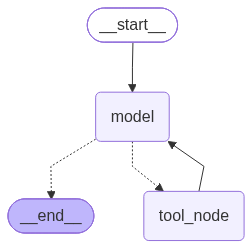

In [13]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API
        )
    )
)

In [ ]:
config = {
    "configurable": {
        "thread_id": 2
    }
}

response = await graph.ainvoke({
    "messages": [HumanMessage(content="When is the next spaceX launch?")], 
}, config=config)

response

{'messages': [HumanMessage(content='When is the next spaceX launch?', additional_kwargs={}, response_metadata={}, id='91954b9b-34da-4508-a25e-873701957694'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_79bIYNNMGIiMMRKhK23NywKi', 'function': {'arguments': '{"query":"next SpaceX launch","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 1195, 'total_tokens': 1218, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_72f05258df', 'id': 'chatcmpl-EEe9djfWfrGVnDg4vTnFfuMIlg3en', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a01b04-256b-74e3-ab41-24e43253ba9c-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'next 

In [ ]:
config = {
    "configurable": {
        "thread_id": 5
    }
}

# Use async for to iterate over the async generator
async for event in graph.astream_events({
    "messages": [HumanMessage(content="When is the next spacex launch?")],
}, config=config, version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='When is the next spacex launch?', additional_kwargs={}, response_metadata={})]}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a01b05-0441-78e2-a1f3-f65abe3555ba', 'metadata': {'thread_id': 5, 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='When is the next spacex launch?', additional_kwargs={}, response_metadata={}, id='91e1b7ff-9bc2-4eb2-a16f-f8245fd54980')]}}, 'name': 'model', 'tags': ['graph:step:1'], 'run_id': '01a01b05-0442-7241-a353-20ea29bb2914', 'metadata': {'thread_id': 5, 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'model', 'langgraph_triggers': ('branch:to:model',), 'langgraph_path': ('__pregel_pull', 'model'), 'langgraph_checkpoint_ns': 'model:a73aa010-06e1-ec72-2845-21a5d8818db8'}, 'parent_ids': ['01a01b05-0441-78e2-a1f3-f65abe3555ba']}
{'event': 'on_chain_start', 'data': {'input': 